# fMRI Denoising Pipeline - Example Usage

This notebook demonstrates how to use the denoising pipeline to extract time-series from BOLD fMRI data.

In [1]:
import sys
sys.path.append('..')  # Add parent directory to path

from denoising import DenoisingPipeline
from denoising.config import load_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 1. Load Configuration

First, load the configuration file that defines atlas, denoising, and confounds parameters.

In [2]:
config = load_config('../configs/strategy_4.yaml')

print(f"Atlas: {config.atlas.name} with {config.atlas.n_regions} regions")
print(f"Smoothing FWHM: {config.denoising.smoothing_fwhm} mm")
print(f"Standardization: {config.denoising.standardize}")
print(f"Standardization OF CONFOUNDS: {config.denoising.standardize_confounds}")

Atlas: schaefer_2018 with 400 regions
Smoothing FWHM: 4.0 mm
Standardization: None
Standardization OF CONFOUNDS: True


## 2. Initialize Pipeline

Create a `DenoisingPipeline` instance with the configuration.

In [3]:
pipeline = DenoisingPipeline(config)
print("Pipeline initialized successfully")

Pipeline initialized successfully


## 3. Process a Single Subject

Specify paths to BOLD and confounds files, then run the pipeline.

In [5]:
# Update these paths to your data
bold_path = r"/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29006/ses-1/func/sub-29006_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
output_dir = "../output"

# Run the pipeline
output_file = pipeline.process_subject(bold_path, output_dir)
print(f"Output saved to: {output_file[1]}")

[fetch_atlas_schaefer_2018] Dataset found in /home/tm/nilearn_data/schaefer_2018
Output saved to: ../output/sub-29006/ses-1/time-series/29006_1_rest_1_atlas-schaefer_2018.csv


## 4. Load and Inspect Results

Load the extracted time-series and explore the data.

In [6]:
# Load the time-series
timeseries = pd.read_csv(output_file[1])
print(f"Time-series shape: {timeseries.shape}")
print(f"\nFirst 5 rows:")
timeseries.head()

Time-series shape: (119, 400)

First 5 rows:


,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_Vis_10,...,7Networks_RH_Default_PFCdPFCm_13,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2,7Networks_RH_Default_pCunPCC_3,7Networks_RH_Default_pCunPCC_4,7Networks_RH_Default_pCunPCC_5,7Networks_RH_Default_pCunPCC_6,7Networks_RH_Default_pCunPCC_7,7Networks_RH_Default_pCunPCC_8,7Networks_RH_Default_pCunPCC_9
0,-0.048664,-0.082393,-0.303726,-0.501707,-0.110927,0.192168,-0.157265,-0.107438,0.034316,-0.553096,...,0.112650,-0.562813,-0.174392,-0.565848,-0.202276,-0.116422,-0.189249,-0.232511,0.100806,-0.423760
1,0.119323,0.920106,1.463596,2.056554,-0.949489,-1.150311,0.723646,-0.287479,-0.577736,-1.545410,...,0.158624,-1.341872,0.773794,1.081549,-2.061117,-1.958003,-0.610149,0.542044,1.078182,1.282305
2,-0.388616,-0.744184,-0.352795,-1.096149,-1.807008,-0.842951,-0.835692,-0.829824,-1.908093,-0.415682,...,0.069352,-1.166581,1.396251,2.214217,0.011803,0.895171,0.887179,1.212530,1.730481,0.999859
3,0.019440,-2.172734,-0.647693,-1.456165,2.301517,2.831886,-2.568606,-0.580474,2.072330,0.401940,...,0.576045,-0.091303,1.202765,1.642672,1.727743,2.774996,-0.009292,0.439327,-0.059657,-0.912044
4,0.946478,-0.939380,1.025997,2.076623,4.841577,3.206100,-1.412668,-0.109267,4.371127,-0.341496,...,0.811172,0.315451,-0.626609,-1.598480,0.056747,-0.683314,-2.617275,-1.309006,-2.606521,-1.923929


## 5. Visualize Time-Series

Plot time-series for a few regions.

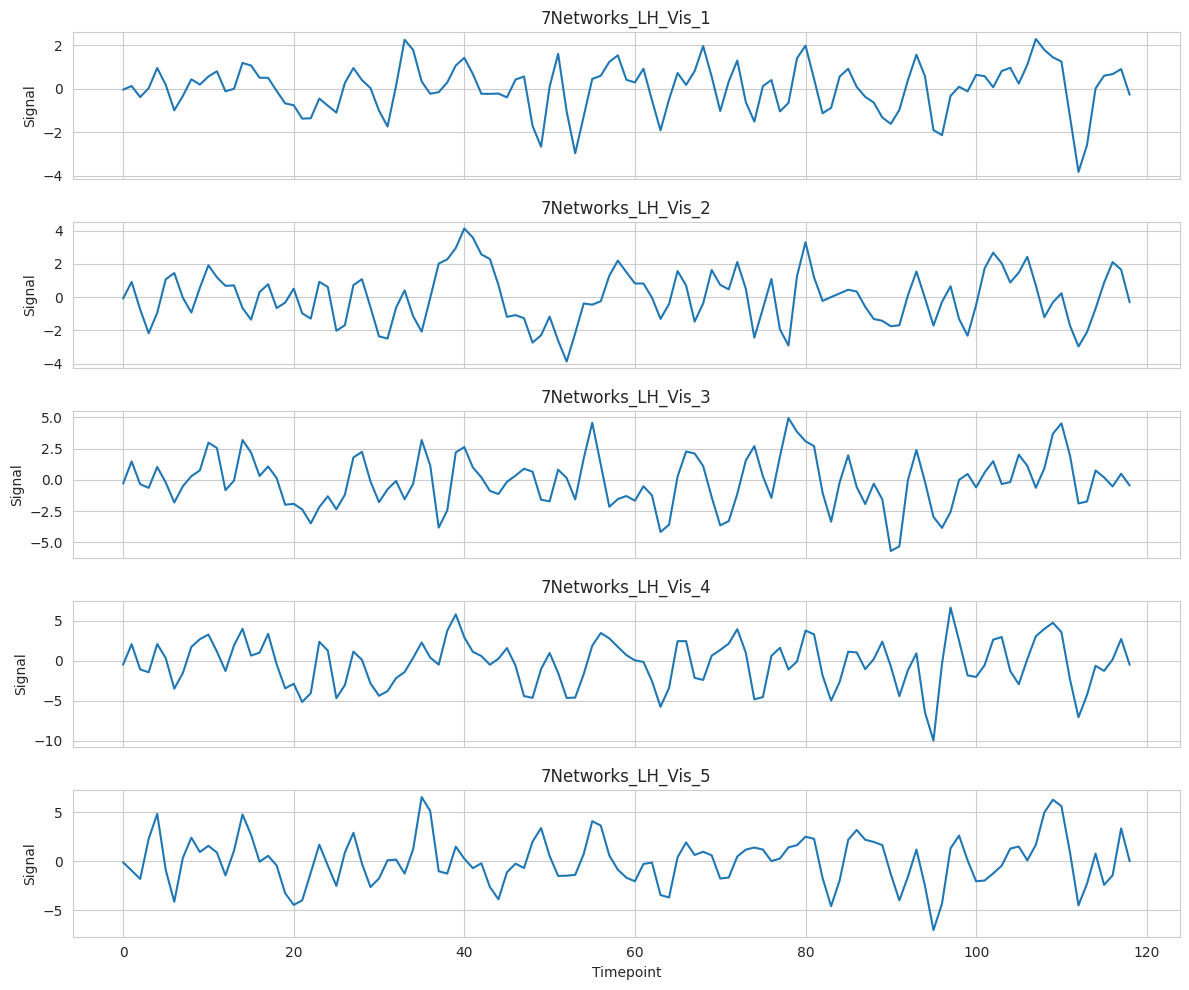

In [7]:
# Plot first 5 regions
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i, ax in enumerate(axes):
    region = timeseries.columns[i]
    ax.plot(timeseries[region].values)
    ax.set_ylabel('Signal')
    ax.set_title(region)

axes[-1].set_xlabel('Timepoint')
plt.tight_layout()
plt.show()

## 6. Correlation Matrix

Compute and visualize the correlation matrix between regions.

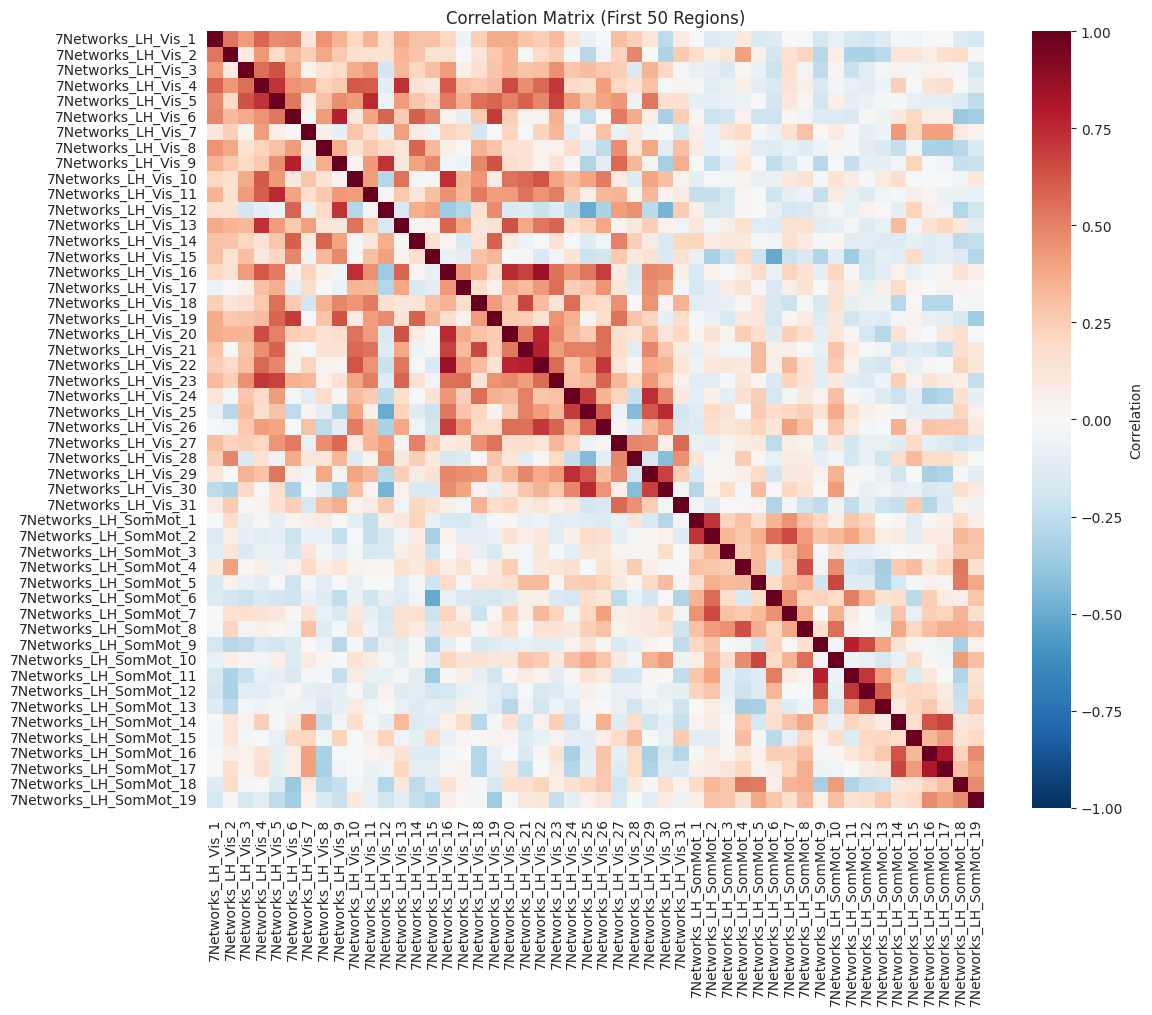

In [8]:
# Compute correlation matrix (subset of regions for visualization)
n_regions_plot = 50
corr_matrix = timeseries.iloc[:, :n_regions_plot].corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1, 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix (First {n_regions_plot} Regions)')
plt.tight_layout()
plt.show()

## 7. Batch Processing (Legacy Mode)

Process multiple subjects using a list of file paths.

In [8]:
# Define subjects to process
subjects = [
    {
        "bold_path": "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29006/ses-1/func/sub-29006_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
    },
    {
        "bold_path": "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29007/ses-1/func/sub-29007_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
    }
]
output_dir = "../output"
# Run batch processing
outputs = pipeline.process_batch(subjects, output_dir)
# print(f"Processed {len([o for o in outputs if o])} subjects successfully")

In [9]:
print(f"Processed {len([o for o in outputs if o])} subjects successfully")


Processed 2 subjects successfully


## 8. BIDS Mode Processing

Process subjects using BIDS dataset structure. This mode automatically handles multiple sessions and runs.

In [6]:
from denoising.io.file_handler import BIDSFileLoader
from denoising.config.schemas import BIDSConfig

# Define BIDS dataset path and parameters
bids_path = "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives"  # Update this path

# Create BIDS file loader
bids_loader = BIDSFileLoader(bids_path)

# Get all subjects in the dataset
all_subjects = bids_loader.get_all_subjects()
print(f"Found {len(all_subjects)} subjects in dataset")
print(f"Subjects: {all_subjects[:5]}...")  # Show first 5

Found 58 subjects in dataset
Subjects: ['29006', '29007', '29008', '29009', '29010']...


In [7]:
# IMPORTANT: Specify a writable output directory!
# Do NOT use the BIDS dataset path if it's read-only
output_dir = "../output"  # Or any writable directory

# Process a single subject (all sessions/runs)
#subject_id = ['29006', '29007', '29008', '29009',] # Update with actual subject ID
subject_id = 'all'
outputs = pipeline.process_batch(subject_id, output_dir=output_dir, bids_loader=bids_loader)

print(f"\nProcessed {len(outputs)} files for subject {subject_id}")

[fetch_atlas_schaefer_2018] Dataset found in /home/tm/nilearn_data/schaefer_2018


KeyboardInterrupt: 

In [12]:
# Process multiple subjects
subjects_to_process = ["29006", "29007", "29008"]  # Update with actual subject IDs
outputs = pipeline.process_batch(subjects_to_process, output_dir=output_dir, bids_loader=bids_loader)

print(f"\nProcessed {len(outputs)} files across {len(subjects_to_process)} subjects")
successful = [o for o in outputs if o]
print(f"Successful: {len(successful)}/{len(outputs)}")

### Output Directory Structure

In BIDS mode, outputs are saved in a BIDS-compliant structure:
```
{output_dir}/
├── sub-{subject}/
│   ├── ses-{session}/
│   │   └── time-series/
│   │       └── {subject}_{session}_{task}_{run}_atlas-{atlas_name}.csv
│   └── time-series/
│       └── {subject}_{task}_{run}_atlas-{atlas_name}.csv
```

**Important:** The `output_dir` must be a writable directory. Do not use the BIDS dataset path if it's read-only (e.g., shared storage). Instead, specify a local writable directory like `./output` or `~/fmri_results`.